# Notebook 3 — Estatística pareada no pipeline log-mel

O Notebook 2 produz três reconstruções da mesma intervenção definida em log-mel.

As comparações principais são:

$$
\Delta AUC_{\mathrm{orig}}
=
AUC_{\mathrm{OP}}
-
AUC_{\mathrm{GL\_ORIG64}}
$$

e:

$$
\Delta AUC_{\mathrm{rand}}
=
AUC_{\mathrm{OP}}
-
AUC_{\mathrm{GL\_RAND64}}.
$$

Também analisamos o erro de realização no próprio domínio log-mel.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binomtest, spearmanr

ART = Path("artifacts_logmel")

RESULTS_PATH = (
    ART
    /
    "perturbation_results_logmel.csv"
)

assert RESULTS_PATH.exists(), (
    "Execute primeiro o Notebook 2 log-mel."
)

df = pd.read_csv(
    RESULTS_PATH
)

print("Linhas:", len(df))
print("Operadores:", sorted(df["operator"].unique()))

required = {
    "OP",
    "GL_ORIG64",
    "GL_RAND64"
}

missing = (
    required
    -
    set(df["operator"].unique())
)

assert not missing, (
    f"Operadores ausentes: {sorted(missing)}"
)

display(df.head())


Linhas: 1200
Operadores: ['GL_ORIG64', 'GL_RAND64', 'OP']


,sample_id,true_label,target_class,direction,budget,operator,full_logit,perturbed_logit,Q,logmel_target_NRMSE,stft_magnitude_target_NRMSE,waveform_gap_vs_OP,magnitude_gap_vs_OP,logmel_gap_vs_OP,phase_gap_vs_original_rad,gl_random_seed
0,0,0,0,OUT,0.1,OP,-0.027177,-0.027644,0.000467,0.274646,0.303695,0.000000,0.000000,0.000000,0.000000,NaN
1,0,0,0,OUT,0.1,GL_ORIG64,-0.035430,-0.035855,0.000425,0.316326,0.070561,0.643040,0.307878,0.091704,0.658225,NaN
2,0,0,0,OUT,0.1,GL_RAND64,-0.035756,-0.036134,0.000378,0.317268,0.067583,1.434515,0.314461,0.093183,1.566293,42.0
3,0,0,0,OUT,0.2,OP,-0.027177,-0.027832,0.000655,0.274694,0.303731,0.000000,0.000000,0.000000,0.000000,NaN
4,0,0,0,OUT,0.2,GL_ORIG64,-0.035430,-0.036031,0.000601,0.316380,0.070574,0.643116,0.307920,0.091717,0.689022,NaN


## 1. AUC das curvas

Para cada amostra, direção e operador:

$$
AUC_R
=
\int Q_R(b)\,db.
$$


In [2]:
auc_rows = []

for (sample_id, direction, operator), group in df.groupby(
    ["sample_id", "direction", "operator"]
):
    group = group.sort_values(
        "budget"
    )

    auc = np.trapezoid(
        group["Q"].to_numpy(),
        group["budget"].to_numpy()
    )

    auc_rows.append({
        "sample_id": sample_id,
        "direction": direction,
        "operator": operator,
        "AUC": float(auc)
    })

auc_long = pd.DataFrame(
    auc_rows
)

auc_wide = (
    auc_long
    .pivot(
        index=[
            "sample_id",
            "direction"
        ],
        columns="operator",
        values="AUC"
    )
    .reset_index()
)

auc_wide.columns.name = None

auc_wide[
    "delta_AUC_OP_minus_GL_ORIG64"
] = (
    auc_wide["OP"]
    -
    auc_wide["GL_ORIG64"]
)

auc_wide[
    "delta_AUC_OP_minus_GL_RAND64"
] = (
    auc_wide["OP"]
    -
    auc_wide["GL_RAND64"]
)

display(auc_wide.head())


,sample_id,direction,GL_ORIG64,GL_RAND64,OP,delta_AUC_OP_minus_GL_ORIG64,delta_AUC_OP_minus_GL_RAND64
0,0,IN,0.059087,0.059247,0.053659,-0.005429,-0.005588
1,0,OUT,-0.000225,-0.000309,0.000096,0.000322,0.000405
2,1,IN,0.004793,0.004946,0.004705,-0.000089,-0.000242
3,1,OUT,0.000169,0.000167,0.000192,0.000022,0.000025
4,2,IN,0.030723,0.030831,0.026902,-0.003821,-0.003929


## 2. Estatística pareada simples

Usamos:

- média;
- mediana;
- bootstrap de 95% para a média;
- paired sign-flip test;
- exact sign test.

Aplicamos Holm às quatro análises principais: duas comparações × duas direções.


In [3]:
def bootstrap_mean_ci(
    values,
    n_boot=10_000,
    seed=42
):
    values = np.asarray(
        values,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    boot_means = np.empty(
        n_boot
    )

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True
        )

        boot_means[i] = (
            sample.mean()
        )

    low, high = np.quantile(
        boot_means,
        [0.025, 0.975]
    )

    return float(low), float(high)


def sign_flip_test(
    values,
    n_perm=20_000,
    seed=42
):
    values = np.asarray(
        values,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    observed = abs(
        values.mean()
    )

    extreme = 0

    for _ in range(n_perm):
        signs = rng.choice(
            [-1.0, 1.0],
            size=len(values)
        )

        permuted = abs(
            np.mean(
                values * signs
            )
        )

        if permuted >= observed:
            extreme += 1

    return (
        extreme + 1
    ) / (
        n_perm + 1
    )


def holm_adjust(
    p_values
):
    p_values = np.asarray(
        p_values,
        dtype=float
    )

    m = len(p_values)
    order = np.argsort(
        p_values
    )

    ordered = p_values[
        order
    ]

    adjusted_ordered = np.empty(
        m
    )

    previous = 0.0

    for i, p in enumerate(ordered):
        adjusted = min(
            1.0,
            (m - i) * p
        )

        previous = max(
            previous,
            adjusted
        )

        adjusted_ordered[
            i
        ] = previous

    adjusted = np.empty(
        m
    )

    adjusted[
        order
    ] = adjusted_ordered

    return adjusted


In [4]:
comparisons = {
    "OP_vs_GL_ORIG64":
        "delta_AUC_OP_minus_GL_ORIG64",

    "OP_vs_GL_RAND64":
        "delta_AUC_OP_minus_GL_RAND64"
}

summary_rows = []

for comparison, delta_column in comparisons.items():
    for direction, group in auc_wide.groupby(
        "direction"
    ):
        values = group[
            delta_column
        ].to_numpy(
            dtype=float
        )

        ci_low, ci_high = bootstrap_mean_ci(
            values
        )

        p_flip = sign_flip_test(
            values
        )

        nonzero = values[
            values != 0
        ]

        n_positive = int(
            (nonzero > 0).sum()
        )

        n_negative = int(
            (nonzero < 0).sum()
        )

        if len(nonzero) > 0:
            p_sign = binomtest(
                k=min(
                    n_positive,
                    n_negative
                ),
                n=len(nonzero),
                p=0.5,
                alternative="two-sided"
            ).pvalue
        else:
            p_sign = 1.0

        summary_rows.append({
            "comparison": comparison,
            "direction": direction,
            "N": len(values),
            "mean_delta_AUC":
                float(values.mean()),
            "median_delta_AUC":
                float(np.median(values)),
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "positive": n_positive,
            "negative": n_negative,
            "p_sign_flip_raw": p_flip,
            "p_sign_test": p_sign
        })

summary = pd.DataFrame(
    summary_rows
)

summary[
    "p_sign_flip_Holm"
] = holm_adjust(
    summary[
        "p_sign_flip_raw"
    ].to_numpy()
)

display(summary)


,comparison,direction,N,mean_delta_AUC,median_delta_AUC,CI95_low,CI95_high,positive,negative,p_sign_flip_raw,p_sign_test,p_sign_flip_Holm
0,OP_vs_GL_ORIG64,IN,40,-0.000465,-0.000338,-0.001616,0.000677,15,25,0.423179,0.15386,0.750162
1,OP_vs_GL_ORIG64,OUT,40,-0.001188,0.000078,-0.001978,-0.000454,25,15,0.003550,0.15386,0.010649
2,OP_vs_GL_RAND64,IN,40,-0.000556,-0.000542,-0.001788,0.000673,15,25,0.375081,0.15386,0.750162
3,OP_vs_GL_RAND64,OUT,40,-0.001607,0.000106,-0.002575,-0.000693,25,15,0.001700,0.15386,0.006800


## 3. Erro de realização no domínio que a CNN observa

O Notebook 2 mede:

$$
E_L
=
\frac{
\left\|
\widetilde{L}
-
L(\widetilde{x})
\right\|_2
}{
\left\|
\widetilde{L}
\right\|_2
}.
$$

Esse erro é especialmente importante porque a perturbação foi definida em log-mel.

Primeiro resumimos $E_L$ por operador.


In [5]:
realization_summary = (
    df
    .groupby("operator")[
        [
            "logmel_target_NRMSE",
            "stft_magnitude_target_NRMSE"
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
)

display(realization_summary)


logmel_target_NRMSE                     stft_magnitude_target_NRMSE  \
                         mean    median       std                        mean   
operator                                                                        
GL_ORIG64            0.162584  0.109564  0.153335                    0.061237   
GL_RAND64            0.167566  0.112058  0.151655                    0.069781   
OP                   0.168855  0.129221  0.135720                    0.209523   

                               
             median       std  
operator                       
GL_ORIG64  0.055327  0.029699  
GL_RAND64  0.063563  0.028734  
OP         0.210756  0.073129

## 4. O erro de realização acompanha a diferença downstream?

Para cada operador Griffin–Lim, relacionamos:

$$
E_L
$$

com:

$$
|\Delta AUC|.
$$

A correlação é exploratória e não estabelece causalidade.


In [6]:
diagnostic_rows = []

spec = [
    (
        "GL_ORIG64",
        "delta_AUC_OP_minus_GL_ORIG64"
    ),
    (
        "GL_RAND64",
        "delta_AUC_OP_minus_GL_RAND64"
    )
]

for operator, delta_column in spec:

    diag = (
        df[
            df["operator"] == operator
        ]
        .groupby(
            [
                "sample_id",
                "direction"
            ]
        )[
            [
                "logmel_target_NRMSE",
                "stft_magnitude_target_NRMSE",
                "waveform_gap_vs_OP",
                "logmel_gap_vs_OP"
            ]
        ]
        .mean()
        .reset_index()
    )

    joined = auc_wide[
        [
            "sample_id",
            "direction",
            delta_column
        ]
    ].merge(
        diag,
        on=[
            "sample_id",
            "direction"
        ]
    )

    joined[
        "abs_delta_AUC"
    ] = np.abs(
        joined[
            delta_column
        ]
    )

    for direction, group in joined.groupby(
        "direction"
    ):
        for metric in [
            "logmel_target_NRMSE",
            "stft_magnitude_target_NRMSE",
            "waveform_gap_vs_OP",
            "logmel_gap_vs_OP"
        ]:
            rho, p = spearmanr(
                group[metric],
                group[
                    "abs_delta_AUC"
                ]
            )

            diagnostic_rows.append({
                "operator": operator,
                "direction": direction,
                "metric": metric,
                "rho": rho,
                "p_value": p
            })

diagnostic_summary = pd.DataFrame(
    diagnostic_rows
)

display(diagnostic_summary)


,operator,direction,metric,rho,p_value
0,GL_ORIG64,IN,logmel_target_NRMSE,0.251970,0.116766
1,GL_ORIG64,IN,stft_magnitude_target_NRMSE,0.146154,0.368178
2,GL_ORIG64,IN,waveform_gap_vs_OP,0.088931,0.585276
3,GL_ORIG64,IN,logmel_gap_vs_OP,-0.044465,0.785283
4,GL_ORIG64,OUT,logmel_target_NRMSE,0.114822,0.480494
5,GL_ORIG64,OUT,stft_magnitude_target_NRMSE,0.236398,0.141939
6,GL_ORIG64,OUT,waveform_gap_vs_OP,0.092871,0.568696
7,GL_ORIG64,OUT,logmel_gap_vs_OP,0.282552,0.077305
8,GL_RAND64,IN,logmel_target_NRMSE,0.297186,0.062562
9,GL_RAND64,IN,stft_magnitude_target_NRMSE,0.254597,0.112875


## 5. Visualizar os contrastes pareados


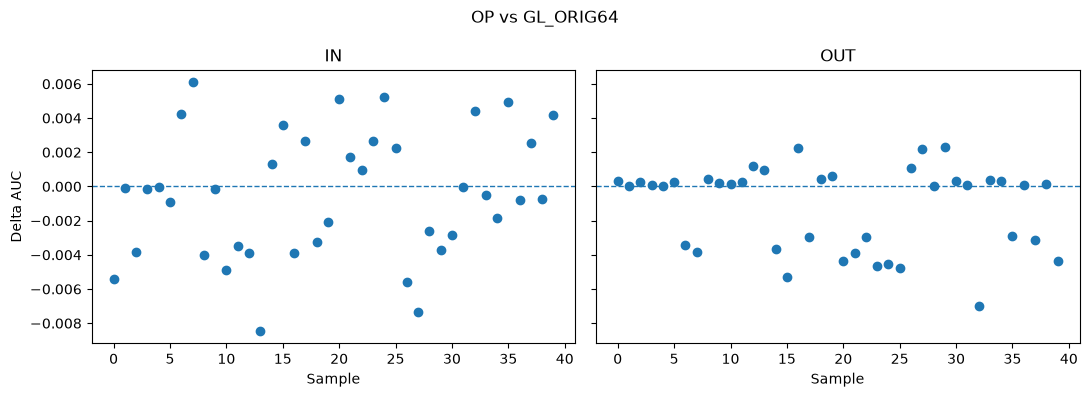

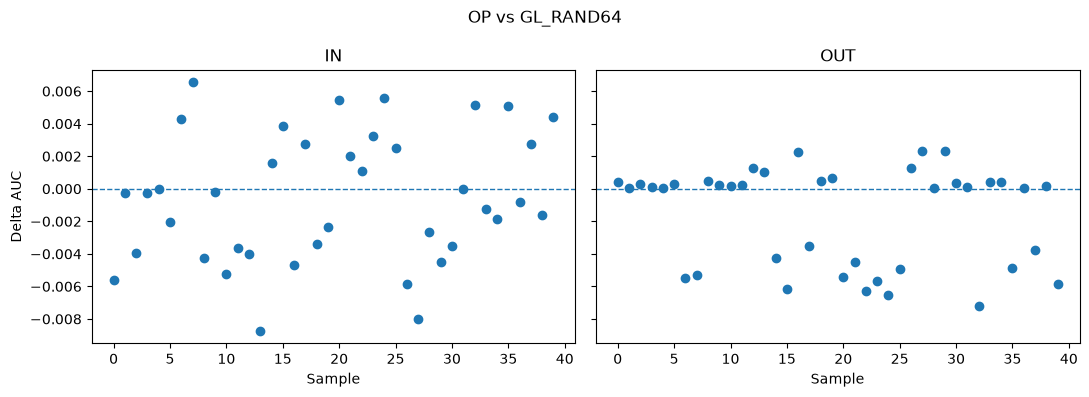

In [7]:
for title, column in [
    (
        "OP vs GL_ORIG64",
        "delta_AUC_OP_minus_GL_ORIG64"
    ),
    (
        "OP vs GL_RAND64",
        "delta_AUC_OP_minus_GL_RAND64"
    )
]:

    directions = sorted(
        auc_wide[
            "direction"
        ].unique()
    )

    fig, axes = plt.subplots(
        1,
        len(directions),
        figsize=(11, 4),
        sharey=True
    )

    if len(directions) == 1:
        axes = [axes]

    for ax, direction in zip(
        axes,
        directions
    ):
        part = auc_wide[
            auc_wide[
                "direction"
            ] == direction
        ]

        x = np.arange(
            len(part)
        )

        ax.scatter(
            x,
            part[column]
        )

        ax.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        ax.set_title(
            direction
        )

        ax.set_xlabel(
            "Sample"
        )

    axes[0].set_ylabel(
        "Delta AUC"
    )

    fig.suptitle(
        title
    )

    plt.tight_layout()
    plt.show()


## 6. Salvar


In [8]:
summary.to_csv(
    ART / "statistical_summary_logmel.csv",
    index=False
)

auc_wide.to_csv(
    ART / "sample_auc_contrasts_logmel.csv",
    index=False
)

realization_summary.to_csv(
    ART / "realization_summary_logmel.csv"
)

diagnostic_summary.to_csv(
    ART / "realization_vs_auc_logmel.csv",
    index=False
)

print("Notebook 3 concluído.")
print("Resultados em:", ART.resolve())


Notebook 3 concluído.
Resultados em: /home/las/Bioacustica - Periodico/artifacts_logmel


# Pipeline final

$$
\boxed{\text{waveform}}
\rightarrow
\boxed{\text{log-mel}}
\rightarrow
\boxed{\text{LIME}}
\rightarrow
\boxed{\text{perturbação log-mel}}
\rightarrow
\boxed{\text{inversão mel}}
\rightarrow
\boxed{\text{OP / GL}}
\rightarrow
\boxed{\text{log-mel realizado}}
\rightarrow
\boxed{\text{CNN}}
\rightarrow
\boxed{\text{estatística pareada}}
$$
